## 1. Problem Identification  In Detail

To build a personalized book recommendation system that suggests similar books based on a user’s past ratings and preferences, leveraging user-item interaction data.

How:
By using K-Nearest Neighbors (KNN) over a user-book rating matrix to find books that are closely related to a target book (based on collaborative patterns from other users).

Why:
To help users discover books they are likely to enjoy, even if they haven’t rated them yet — improving user experience in book platforms.

## 2. Data Preparation & Exploration

**Import librarys**

In [46]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier

**Read file and define**

In [47]:
book_df = pd.read_csv(
    './input/book-recommendation-dataset/Books.csv',
    sep=',',          # Explicitly set delimiter
    quotechar='"',    # Specify quote character
    low_memory=False,
    on_bad_lines='skip'
)
ratings_df = pd.read_csv('./input/book-recommendation-dataset/Ratings.csv')
user_df = pd.read_csv('./input/book-recommendation-dataset/Users.csv')
user_rating_df = ratings_df.merge(user_df, left_on = 'User-ID', right_on = 'User-ID')


**Column rename**

In [48]:
book_df.rename(columns={
    "Book-Title":"title",
    "Book-Author":"author",
    "Year-Of-Publication":"year",
    "Publisher":"publisher",
    "Image-URL-L":"img_url"},inplace=True)

ratings_df.rename(columns={
    "User-ID":"user_id",
    "Book-Rating":"rating"
},inplace=True)

**Filtering Active Users**



In [49]:
# Filter users who have rated more than 200 books
x = ratings_df['user_id'].value_counts() > 100
y = x[x].index
ratings_df = ratings_df[ratings_df['user_id'].isin(y)]

# Merge with book info
rating_with_books = ratings_df.merge(book_df, on="ISBN")

# Count ratings per book
num_rating = rating_with_books.groupby('title')['rating'].count().reset_index()
num_rating.rename(columns={'rating': 'num_of_rating'}, inplace=True)

# Merge back and filter popular books (at least 50 ratings)
final_rating = rating_with_books.merge(num_rating, on='title')
final_rating = final_rating[final_rating['num_of_rating'] >= 20]

# Drop duplicate user-book pairs
final_rating.drop_duplicates(['user_id', 'title'], inplace=True)


## 3. Feature Engineering

**Split data into training and testing sets**

In [50]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
train_data, test_data = train_test_split(final_rating, test_size=0.2, random_state=42)


**Create pivot table (user-book matrix)**

In [51]:
from scipy.sparse import csr_matrix

book_pivot = train_data.pivot_table(columns='user_id', index='title', values='rating')
book_pivot.fillna(0, inplace=True)

book_sparse = csr_matrix(book_pivot)

In [52]:
book_pivot


user_id,183,254,507,882,1424,1435,1733,1903,2033,2110,...,276018,276463,276680,276925,277427,277478,277639,278137,278188,278418
title,,,,,,,,,,,,,,,,,,,,,
'Salem's Lot,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10 Lb. Penalty,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
101 Dalmatians,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16 Lighthouse Road,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1984,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zoya,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"\O\"" Is for Outlaw""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"\Surely You're Joking, Mr. Feynman!\"": Adventures of a Curious Character""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Model Selection & Training

**Model Training**

In [53]:
from sklearn.neighbors import NearestNeighbors

model = NearestNeighbors(algorithm='brute')
model.fit(book_sparse)

NearestNeighbors(algorithm='brute')

**Recommendation Function**

In [54]:
distance, suggestion =model.kneighbors(book_pivot.iloc[237,:].values.reshape(1,-1), n_neighbors=6)

**Example Recommendation Call**

In [55]:
for i in range(len(suggestion)):
    print(book_pivot.index[suggestion[i]])

def recommend_book(book_name):
    book_id = np.where(book_pivot.index == book_name)[0][0]
    distance, suggestion = model.kneighbors(book_pivot.iloc[book_id,:].values.reshape(1,-1), n_neighbors=6)

    for i in range(len(suggestion)):
        books = book_pivot.index[suggestion[i]]
        for j in books:
            print(j)


Index(['Ancient Evenings', 'Hooligans', 'A Monk Swimming : A Memoir',
       'An Ocean Apart', 'Confessions of an Ex-Girlfriend',
       'Chains of Command'],
      dtype='object', name='title')


In [56]:
book_name='A Bend in the Road'
recommend_book(book_name)

A Bend in the Road
The Letter of the Law
The Tall Pine Polka (Ballantine Reader's Circle)
Carpenter's Lady, The, NEW EDITION
Mary Anne Saves the Day (Baby-Sitters Club, 4)
Johnny Angel


## 5. Model Evaluation

In [57]:
from sklearn.metrics import mean_squared_error

def calculate_rmse(model, book_pivot, test_data):
    """
    Calculate RMSE using the test data.
    model: Trained KNN model
    book_pivot: Pivot table created from train data
    test_data: Test dataset (20% split)
    """
    actual_ratings = []
    predicted_ratings = []

    test_books = test_data['title'].unique()

    for book_name in test_books:
        if book_name not in book_pivot.index:
            continue  # Skip books not in training data

        book_id = np.where(book_pivot.index == book_name)[0][0]
        distance, suggestion = model.kneighbors(book_pivot.iloc[book_id, :].values.reshape(1, -1), n_neighbors=6)

        # Collect neighbors (excluding itself)
        neighbors = book_pivot.index[suggestion[0][1:]]  # skip the first which is itself

# Define default rating (e.g., average of all ratings in test_data)
        default_rating = test_data['rating'].mean()
                # Predicted rating is average of neighbors' ratings
        ratings = []
        for neighbor in neighbors:
            neighbor_ratings = test_data.loc[test_data['title'] == neighbor, 'rating']
            if not neighbor_ratings.empty:
                ratings.append(neighbor_ratings.mean())
        # Avoid empty list error
        if ratings:
            predicted = np.mean(ratings)
        else:
            predicted = default_rating

        # Actual rating is the mean from test data
        actual = test_data[test_data['title'] == book_name]['rating'].mean()

        if not np.isnan(predicted) and not np.isnan(actual):
            predicted_ratings.append(predicted)
            actual_ratings.append(actual)

    # Compute RMSE
    mse = mean_squared_error(actual_ratings, predicted_ratings)
    rmse = np.sqrt(mse)
    return rmse


**Test Result**

In [58]:
rmse_value = calculate_rmse(model, book_pivot, test_data)
print(f"RMSE on the test set: {rmse_value:.4f}")
import pickle


RMSE on the test set: 1.8567


In [59]:
def precision_recall_at_k(model, book_pivot, test_data, k=5):
    """
    Calculate Precision@K and Recall@K.
    model: Trained KNN model
    book_pivot: Pivot table from train data
    test_data: Test dataset
    k: Number of neighbors to recommend
    """
    total_precision = []
    total_recall = []

    test_books = test_data['title'].unique()

    for book_name in test_books:
        if book_name not in book_pivot.index:
            continue  # Skip books not in training

        # Find similar books
        book_id = np.where(book_pivot.index == book_name)[0][0]
        distance, suggestion = model.kneighbors(book_pivot.iloc[book_id, :].values.reshape(1, -1), n_neighbors=k+1)

        recommended_books = book_pivot.index[suggestion[0][1:]]  # Exclude itself (index 0)

        # Ground truth: similar books (assume books that user actually rated similarly)
        true_books = test_data[test_data['title'] == book_name]['user_id'].values

        hits = 0
        for rec_book in recommended_books:
            rec_users = test_data[test_data['title'] == rec_book]['user_id'].values
            # Check if any user overlaps (meaning similar taste)
            if len(np.intersect1d(true_books, rec_users)) > 0:
                hits += 1

        if len(recommended_books) > 0:
            precision = hits / len(recommended_books)
            total_precision.append(precision)

        if len(true_books) > 0:
            recall = hits / len(true_books)
            total_recall.append(recall)

    # Average across all test books
    avg_precision = np.mean(total_precision) if total_precision else 0
    avg_recall = np.mean(total_recall) if total_recall else 0

    return avg_precision, avg_recall


# Example usage:
precision, recall = precision_recall_at_k(model, book_pivot, test_data, k=5)
print(f"Precision@5: {precision:.4f}")
print(f"Recall@5: {recall:.4f}")


Precision@5: 0.1083
Recall@5: 0.0662


In [60]:
books_name = book_pivot.index

## 6. Model Saved

In [61]:

pickle.dump(model, open('Trainedmodel/model.pkl', 'wb'))
pickle.dump(books_name, open('Trainedmodel/books_name.pkl', 'wb'))
pickle.dump(final_rating, open('Trainedmodel/final_rating.pkl', 'wb'))
pickle.dump(book_pivot, open('Trainedmodel/book_pivot.pkl', 'wb'))

## Plot Show

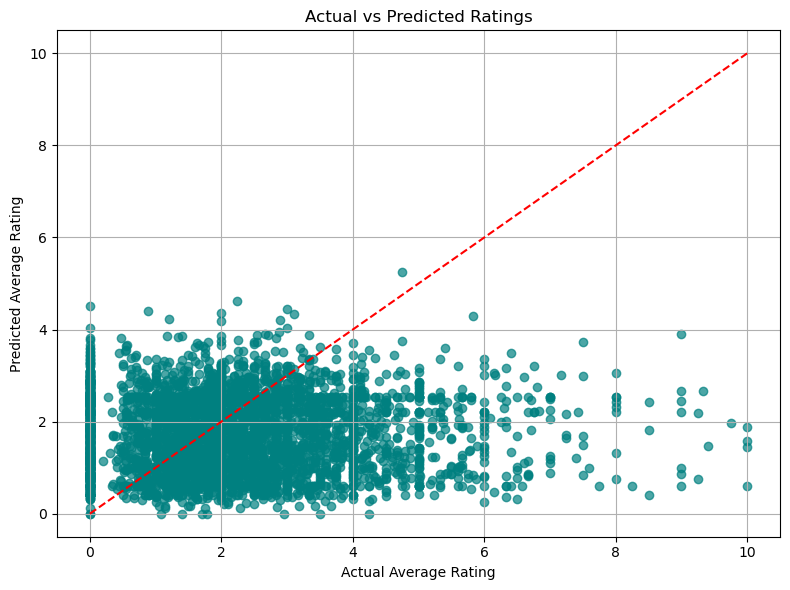

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure you have: test_data, book_pivot, model already defined
actual_ratings = []
predicted_ratings = []
titles = []

for book_name in test_data['title'].unique():
    if book_name not in book_pivot.index:
        continue

    book_id = np.where(book_pivot.index == book_name)[0][0]
    n_neighbors = min(6, len(book_pivot))  # Handle small datasets
    distance, suggestion = model.kneighbors(book_pivot.iloc[book_id, :].values.reshape(1, -1), n_neighbors=n_neighbors)
    
    neighbors = book_pivot.index[suggestion[0][1:]]  # skip self

    predicted = np.mean([
        test_data[test_data['title'] == neighbor]['rating'].mean()
        if neighbor in test_data['title'].values else 0
        for neighbor in neighbors
    ])

    actual = test_data[test_data['title'] == book_name]['rating'].mean()

    if not np.isnan(predicted) and not np.isnan(actual):
        predicted_ratings.append(predicted)
        actual_ratings.append(actual)
        titles.append(book_name)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(actual_ratings, predicted_ratings, alpha=0.7, color='teal')
plt.plot([min(actual_ratings), max(actual_ratings)],
         [min(actual_ratings), max(actual_ratings)], 'r--')
plt.xlabel('Actual Average Rating')
plt.ylabel('Predicted Average Rating')
plt.title('Actual vs Predicted Ratings')
plt.grid(True)
plt.tight_layout()
plt.show()


In [63]:

from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# Reduce dimensionality
pca = PCA(n_components=2)
book_pivot_2d = pca.fit_transform(book_pivot)

# Create a DataFrame for easier plotting
book_2d_df = pd.DataFrame(book_pivot_2d, columns=['x', 'y'])
book_2d_df['title'] = book_pivot.index

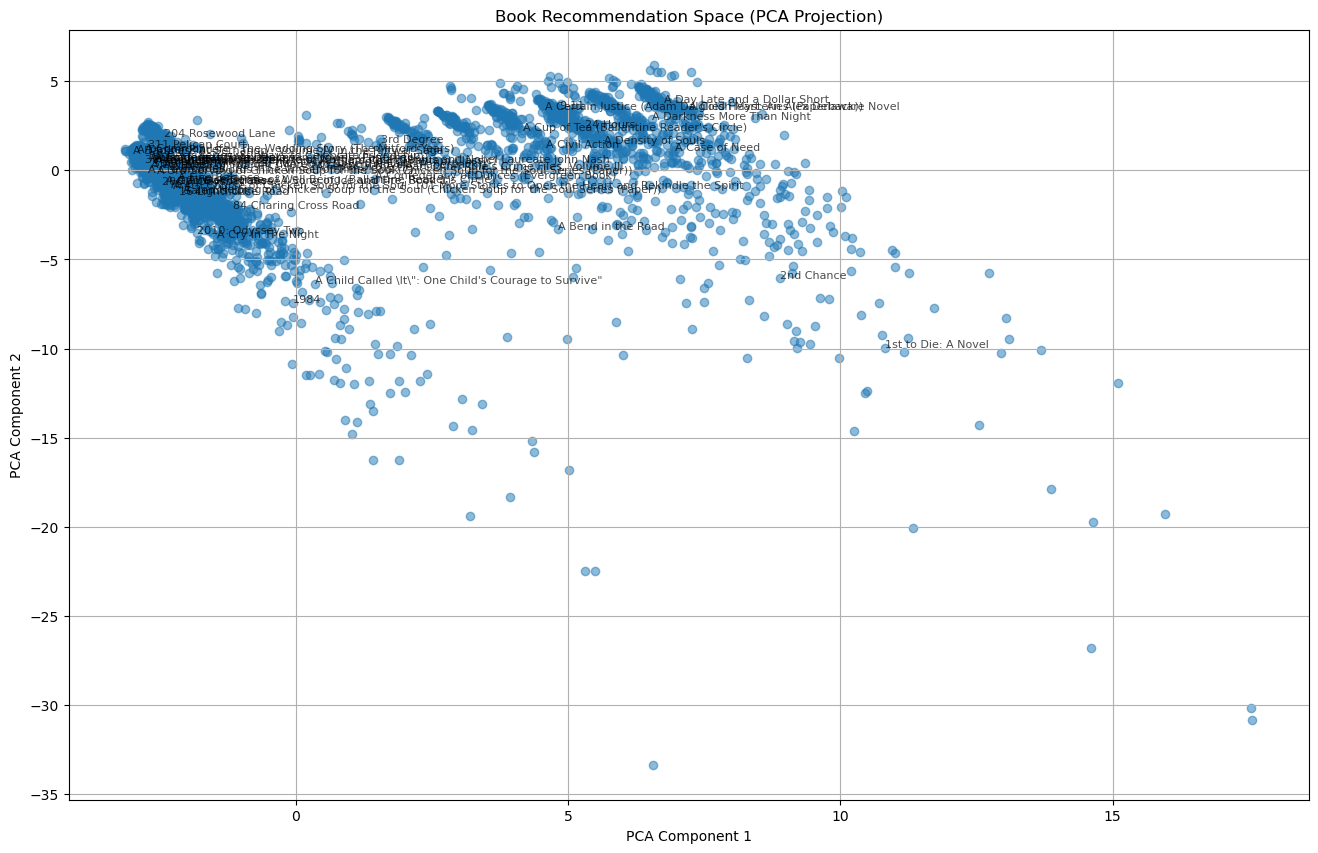

In [64]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensionality for visualization
pca = PCA(n_components=2)
book_pivot_pca = pca.fit_transform(book_pivot)

# Create a DataFrame for easier plotting
pca_df = pd.DataFrame(book_pivot_pca, columns=['PCA1', 'PCA2'], index=book_pivot.index)

# Plot the books in 2D
plt.figure(figsize=(16, 10))
plt.scatter(pca_df['PCA1'], pca_df['PCA2'], alpha=0.5)

# Annotate a few books (optional, not too many to keep plot readable)
for i, title in enumerate(pca_df.index[:50]):  # Only label first 50 books for clarity
    plt.annotate(title, (pca_df.iloc[i]['PCA1'], pca_df.iloc[i]['PCA2']), fontsize=8, alpha=0.7)

plt.title('Book Recommendation Space (PCA Projection)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_17116\1410683273.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


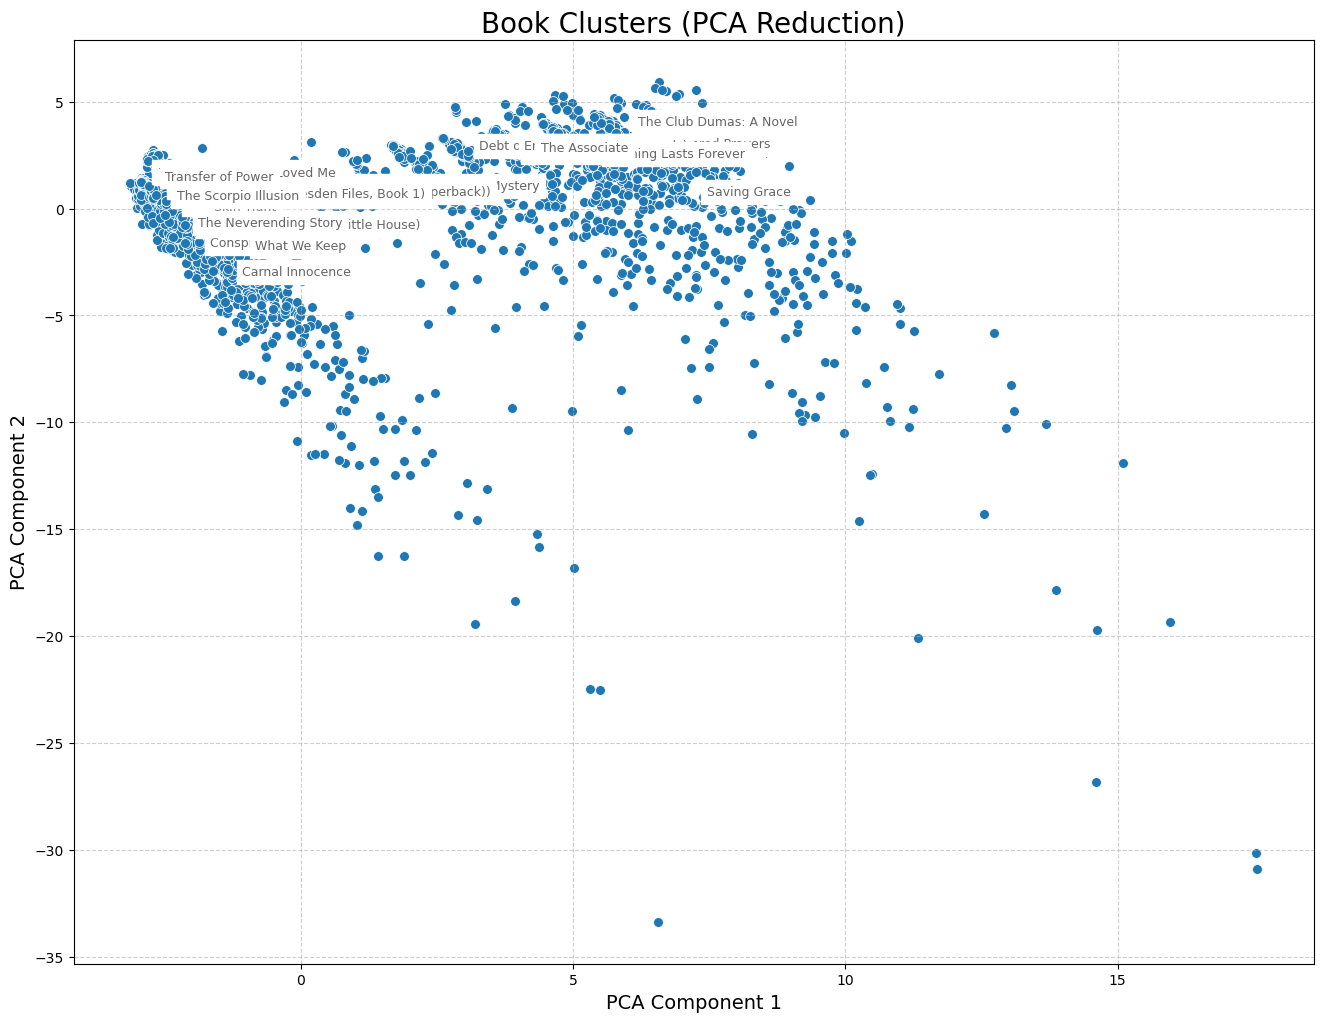

In [65]:
# Create a bigger figure
plt.figure(figsize=(16, 12))

# Use a nicer color palette
sns.scatterplot(
    x='x', y='y',
    data=book_2d_df,
    s=50,  # size of points
    palette="viridis", 
    legend=False
)

# Annotate only a few random books to avoid clutter
# You can change 'step' to control how many to label
step = len(book_2d_df) // 30
for i in range(0, len(book_2d_df), step):
    plt.text(
        book_2d_df.iloc[i]['x']+0.3, 
        book_2d_df.iloc[i]['y']+0.3, 
        book_2d_df.iloc[i]['title'],
        fontsize=9,
        backgroundcolor='white',
        alpha=0.6
    )

plt.title('Book Clusters (PCA Reduction)', fontsize=20)
plt.xlabel('PCA Component 1', fontsize=14)
plt.ylabel('PCA Component 2', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
